Here, we filter the TF anndata object according to the extracted signaling network. We also embed the activity matrix in PCA/UMAP space.

In [1]:
import os
import ast
import json
import joblib
from joblib import Parallel, delayed

from tqdm import tqdm
from tqdm import trange

import numpy as np
import pandas as pd

from scipy.stats import f_oneway, kruskal
from scipy import stats
from sklearn.metrics import normalized_mutual_info_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelBinarizer, LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

from kneed import KneeLocator

import scanpy as sc
import umap

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import preprocess as pp

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [2]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'

In [3]:
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', author + '_sn_ppis.csv'), 
                     index_col = 0)
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'

file_path = os.path.join(data_path, 'processed', author + '_ligand_connections.json')
with open(file_path, 'r') as f:
    ligand_connections = json.load(f)
    
tf_adata = io.read_tfad(file_name = os.path.join(data_path, 'interim', author + 'consensus_tf_activity.h5ad'))


In [7]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'

In [9]:
tf_labels = tf_adata.var.index.unique().tolist()
ppi_nodes = set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist())
retained_drugs = [drug for drug, TFs in ligand_connections.items() if len(TFs) != 0]
retained_TFs = ppi_nodes.intersection(tf_labels)

Filter the TF object to only include those samples / features retained in the signaling network:

In [10]:
n_cells = tf_adata.shape[0]
tf_adata = tf_adata[tf_adata.obs.drug.isin(retained_drugs), sorted(retained_TFs)]
print('{} of {} cells are retained after excluding drugs not present in the signaling network'.format(tf_adata.shape[0], 
                                                                                                     n_cells))

587720 of 713660 cells are retained after excluding drugs not present in the signaling network


In [35]:
n_cells = tf_adata.shape[0]
tf_adata = tf_adata[tf_adata.obs.drug.isin(retained_drugs), sorted(retained_TFs)]
print('{} of {} cells are retained after excluding drugs not present in the signaling network'.format(tf_adata.shape[0], 
                                                                                                     n_cells))

587720 of 713660 cells are retained after excluding drugs not present in the signaling network


In [11]:
obs = tf_adata.obs.copy()
n_cl, n_drug, n_cond = obs.cell_line.nunique(), obs.drug.nunique(), obs.condition.nunique()

print('The final {} conditions span {} cell lines and {} drugs'.format(n_cond, n_cl, n_drug))

The final 280 conditions span 10 cell lines and 28 drugs


In [12]:
url = "https://huggingface.co/datasets/tahoebio/Tahoe-100M/resolve/main/metadata/drug_metadata.parquet"
drug_ds = pd.read_parquet(url)
n_moa = drug_ds[drug_ds.drug.isin(retained_drugs)]['moa-fine'].nunique()

url = 'https://huggingface.co/datasets/tahoebio/Tahoe-100M/resolve/main/metadata/cell_line_metadata.parquet'
cell_line_md = pd.read_parquet(url)
cell_line_md = cell_line_md[cell_line_md.Cell_ID_Cellosaur.isin(tf_adata.obs.cell_line.unique().tolist())]

print('This represents {} moas, {} organs, and {} driver genes'.format(n_moa, 
                                                         cell_line_md.Organ.nunique(), 
                                                         cell_line_md.Driver_Gene_Symbol.nunique()))
print('See notebook 00A for the starting numbers prior to signaling network filtering')

This represents 12 moas, 5 organs, and 39 driver genes
See notebook 00A for the starting numbers prior to signaling network filtering


Only one MOA is lost from the drug filtering.

In [13]:
obs.cell_line.value_counts().unique()

array([58772])

In [14]:
obs.drug.value_counts().unique()

array([20990])

In [15]:
obs.condition.value_counts().unique()

array([2099])

In [16]:
obs.shape[0]

587720

We choose a resolution for Leiden clustering that maximizes the NMI with the condition, emulating the methods from [here](https://doi.org/10.1038/s41467-024-49806-9). We proceed to use this resolution for all downstream analyses.

In [54]:
pp.embed_tf_activity(tf_adata = tf_adata, 
                     scanpy_pca = False, 
                     n_components = 50, 
                     cluster_col_name = 'TF_clusters',
                     resolution = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0], 
                     nmi_label = 'condition', 
                     pc_rank = 'automate',
                     n_neighbors = 15,
                     run_pca = True,
                     run_umap  = True,
                     cluster_data = True)

# write with embeddings and singaling network filterings
tf_adata.obs.drug_target = tf_adata.obs.drug_target.astype(str) # needed for writing
io.write_tfad(tf_adata,
              os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))

/home/hmbaghda/Projects/scLEMBAS/scLEMBAS/preprocess.py:184: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm["X_pca"] = X_pca
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Iterate through leiden resolutions


  0%|                                                     | 0/6 [00:00<?, ?it/s]/home/hmbaghda/Projects/scLEMBAS/scLEMBAS/preprocess.py:317: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata = tf_adata, resolution = res)
100%|██████████████████████████████████████████| 6/6 [1:12:40<00:00, 726.76s/it]


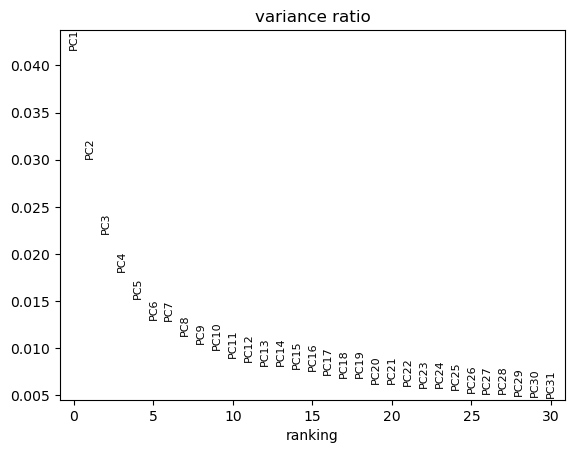

The elbow was automatically identified at PC 11


In [95]:
sc.pl.pca_variance_ratio(tf_adata)
n_pcs = tf_adata.uns['pca']['pca_rank']
print('The elbow was automatically identified at PC {}'.format(n_pcs))

In [92]:
nmi = normalized_mutual_info_score(tf_adata.obs.condition, tf_adata.obs.TF_clusters)
print('Condition NMI was maximized at a resolution of {:.2f} at a value of {:.2f}'.format(tf_adata.uns['leiden']['params']['resolution'], 
                                                                                  nmi))


Condition NMI was maximized at a resolution of 1.00 at a value of 0.41
The automated elbow selection identificed 11 PCs


In [115]:
# subset to 20% of the dataset
n_per_condition = int(np.round(tf_adata.obs['condition'].value_counts().min() * 0.2))

# Subsample indices evenly per condition
sampled_indices = (
    tf_adata.obs.groupby('condition')
    .sample(n=n_per_condition, random_state=seed)
    .index
)
# shufflt
np.random.seed(seed)
sampled_indices=np.random.permutation(sampled_indices)

viz_adata = tf_adata[sampled_indices, :].copy()

/tmp/ipykernel_1861989/3244112921.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tf_adata.obs.groupby('condition')


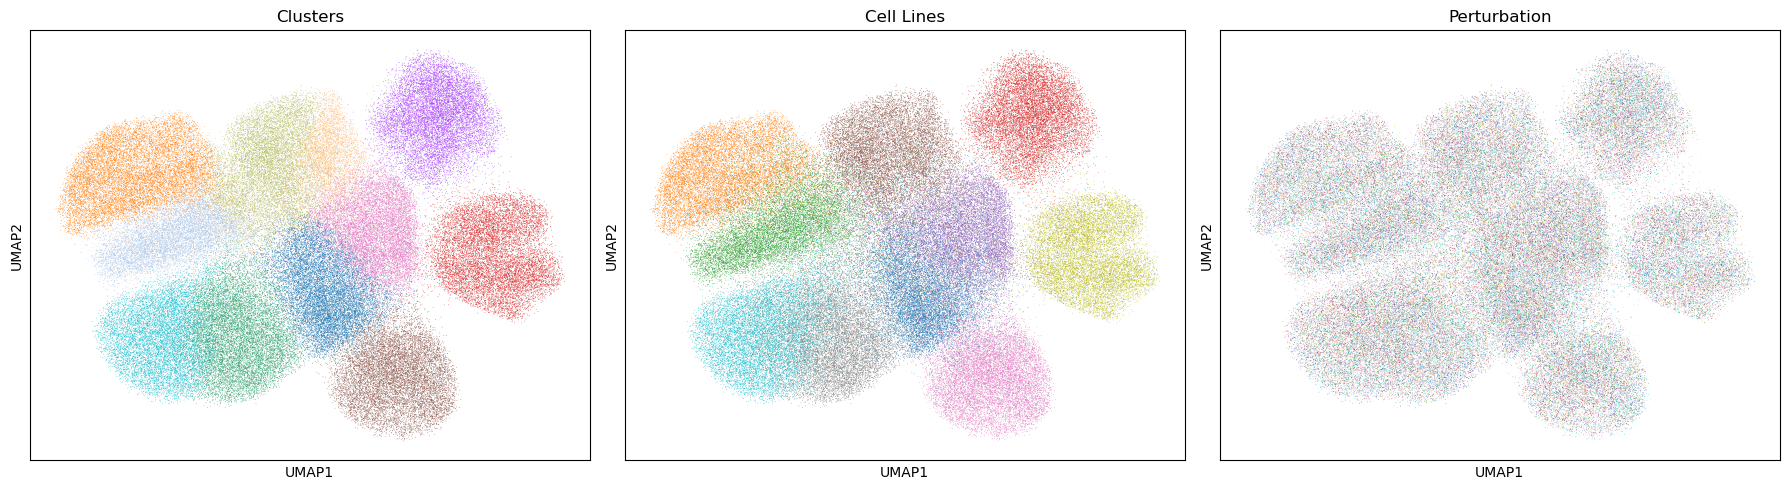

In [122]:
fig, ax = plt.subplots(ncols = 3, figsize = (18, 5))

sc.pl.umap(viz_adata, color='TF_clusters', ax = ax[0], show = False)
ax[0].set_title('Clusters')
ax[0].legend().set_visible(False)
# ax[0].legend(bbox_to_anchor=(-0.1, 1), ncol = 5, bbox_transform=ax[0].transAxes)

sc.pl.umap(viz_adata, color='cell_line', ax = ax[1], show = False)
ax[1].set_title('Cell Lines')
ax[1].legend().set_visible(False)

sc.pl.umap(viz_adata, color='drug', ax = ax[2], show = False)
ax[2].set_title('Perturbation')
ax[2].legend().set_visible(False)
# ax[2].annotate('NMI (TF Clusters, Cell Type):\n {:.2f}'.format(nmi(tf_tf_adata.obs.TF_clusters, tf_tf_adata.obs.celltype)),
#                 xy = (0.015, 0.9), xycoords='axes fraction', fontsize = 9)

fig.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()


In [144]:
pcs = tf_adata.obsm["X_pca"][:, :n_pcs]

res = []
for cov_ in ['drug', 'cell_line']:
    cov = tf_adata.obs[cov_].astype(str)
    enc = OneHotEncoder(drop="first", sparse_output=False)
    cov_encoded = enc.fit_transform(cov.values.reshape(-1, 1))

    r2_scores = []
    for pc_idx in trange(pcs.shape[1]):
        y = pcs[:, pc_idx]
        model = LinearRegression().fit(cov_encoded, y)
        r2 = model.score(cov_encoded, y)
        r2_scores.append({"PC": pc_idx + 1, "R2": r2})

    r2_df = pd.DataFrame(r2_scores)
    r2_df['covariate'] = cov_
    res.append(r2_df)
    
r2_df = pd.concat(res, axis=0, ignore_index=True)


100%|███████████████████████████████████████████| 11/11 [00:02<00:00,  5.16it/s]


Text(0.5, 1.0, 'Top 11 PCs')

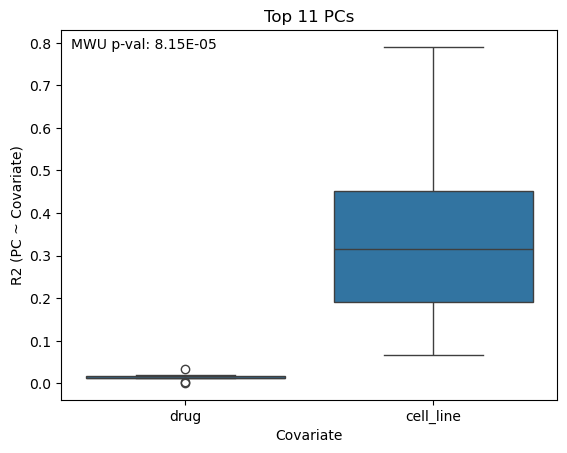

In [165]:
fig, ax = plt.subplots()

pval = stats.mannwhitneyu(r2_df[r2_df.covariate == 'drug'].R2, 
                  r2_df[r2_df.covariate == 'cell_line'].R2).pvalue
sns.boxplot(data = r2_df, x = 'covariate', y = 'R2', ax = ax)

ax.annotate(
    "MWU p-val: {:.2E}".format(pval),
    xy=(0.02, 0.98),
    xycoords="axes fraction",
    ha="left",
    va="top"
)

ax.set_ylabel('R2 (PC ~ Covariate)')
ax.set_xlabel('Covariate')
ax.set_title('Top {} PCs'.format(n_pcs))

In [206]:
top_drug = r2_df[r2_df.covariate == 'drug'].sort_values(by = 'R2', ascending = False)
top_drug_pcs = top_drug.PC[:2].values.tolist()
top_drug

,PC,R2,covariate
3,4,0.032744,drug
8,9,0.020351,drug
2,3,0.018391,drug
4,5,0.017029,drug
9,10,0.016783,drug
1,2,0.013547,drug
5,6,0.012985,drug
6,7,0.012761,drug
7,8,0.012618,drug
10,11,0.003857,drug


In [207]:
top_cell_line = r2_df[r2_df.covariate == 'cell_line'].sort_values(by = 'R2', ascending = False)
top_cell_line_pcs = top_cell_line.PC[:2].values.tolist()
top_cell_line

,PC,R2,covariate
11,1,0.790345,cell_line
12,2,0.561092,cell_line
17,7,0.474862,cell_line
15,5,0.430211,cell_line
14,4,0.402284,cell_line
19,9,0.316075,cell_line
16,6,0.261672,cell_line
13,3,0.222983,cell_line
18,8,0.158028,cell_line
21,11,0.083469,cell_line


Visualize top 2 PCs that separate drugs:

Text(0.5, 1.0, 'Cell Line')

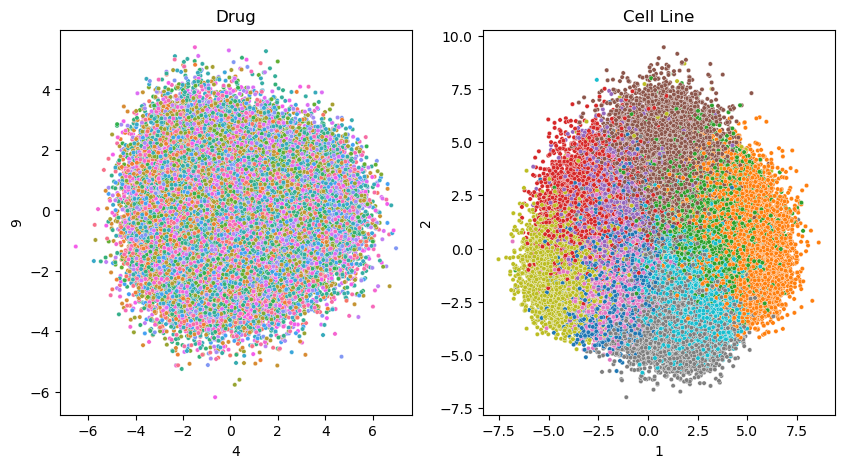

In [208]:
fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))


# DRUG
X_pca = pd.DataFrame(viz_adata.obsm['X_pca'][:, :n_pcs], 
                     columns = range(1, n_pcs + 1))
X_pca = X_pca[top_drug_pcs]
X_pca['drug'] = viz_adata.obs.drug.values
X_pca.columns = X_pca.columns.astype(str)
top_drug_pcs = [str(i) for i in top_drug_pcs]

sns.scatterplot(data = X_pca, x = top_drug_pcs[0], y = top_drug_pcs[1], hue = 'drug', 
               s = 10, ax = ax[0])
ax[0].legend_.remove()
ax[0].set_title('Drug')

# Cell Line
X_pca = pd.DataFrame(viz_adata.obsm['X_pca'][:, :n_pcs], 
                     columns = range(1, n_pcs + 1))
X_pca = X_pca[top_cell_line_pcs]
X_pca['cell_line'] = viz_adata.obs.cell_line.values
X_pca.columns = X_pca.columns.astype(str)
top_cell_line_pcs = [str(i) for i in top_cell_line_pcs]

sns.scatterplot(data = X_pca, x = top_cell_line_pcs[0], y = top_cell_line_pcs[1], hue = 'cell_line', 
               s = 10, ax = ax[1])
ax[1].legend_.remove()
ax[1].set_title('Cell Line')

;

These are clearly separating much more strongly by cell line than perturbation. In the next script, we will attempt to achieve an embedding that demonstrates good drug perturbation separation.